In [81]:
!mkdir food_dataset
!./google-cloud-sdk/bin/gsutil -m cp -r "gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead" ./food_dataset
!./google-cloud-sdk/bin/gsutil -m cp -r "gs://nutrition5k_dataset/nutrition5k_dataset/metadata" ./food_dataset
!./google-cloud-sdk/bin/gsutil -m cp -r "gs://nutrition5k_dataset/nutrition5k_dataset/dish_ids" ./food_dataset

mkdir: cannot create directory ‘food_dataset’: File exists
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1556572657/depth_color.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1556572657/depth_raw.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1556572657/rgb.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1556573514/depth_raw.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1556573514/depth_color.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1556575014/depth_color.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1556575014/depth_raw.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1556575083/depth_color.png...
Copying gs://nutrition5k_dataset/nu

In [1]:
# prompt: create a dataloader for the nutrition5k_dataset. Filenames are located inside the food_dataset/dish_ids/splits/rgb_train_ids.txt for training and  food_dataset/dish_ids/splits/rgb_test_ids.txt for testing.
# for each filename inside the text, the file is located in:  food_dataset/realsense_overhead/<FILENAME>/rgb.png. 

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import csv

class Nutrition5kDataset(Dataset):
    def __init__(self, data_dir, split='train', transform=None):
        self.data_dir = data_dir
        self.split = split
        self.transform = transform

        if split == 'train':
            split_file = os.path.join(data_dir, 'dish_ids', 'splits', 'rgb_train_ids.txt')
        elif split == 'test':
            split_file = os.path.join(data_dir, 'dish_ids', 'splits', 'rgb_test_ids.txt')
        else:
            raise ValueError("Invalid split. Choose 'train' or 'test'.")

        with open(split_file, 'r') as f:
            self.image_ids = [line.strip() for line in f]
            self.image_ids = [image_id for image_id in self.image_ids if os.path.exists(os.path.join(data_dir, 'realsense_overhead', image_id, 'rgb.png'))]
        
        #self.image_ids = os.listdir(os.path.join(data_dir, 'realsense_overhead'))
        #self.image_ids = [image_id for image_id in self.image_ids if os.path.exists(os.path.join(data_dir, 'realsense_overhead', image_id, 'rgb.png'))]
        print(len(self.image_ids))

    def __len__(self):
        return len(self.image_ids)

    def get_csv_line(self, image_id):
      csv_files = [
          "./food_dataset/metadata/dish_metadata_cafe1.csv",
          #"./food_dataset/metadata/dish_metadata_cafe2.csv"
      ]

      for csv_file in csv_files:
          if os.path.exists(csv_file):
              with open(csv_file, 'r', encoding='utf-8') as file:
                  reader = csv.reader(file) 
                  for row in reader:
                      if row and row[0] == image_id:  
                          return row  
      return None  

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.data_dir, 'realsense_overhead', image_id, 'rgb.png')
        
        try:
          image = Image.open(image_path).convert('RGB')
        except FileNotFoundError:
          print(f"Warning: Image file not found at {image_path}. Skipping.")
          # Return a placeholder or handle the error as needed
          return torch.zeros(size=((3, 224, 224))), None

        if self.transform:
            image = self.transform(image)
        
        target = ",".join(self.get_csv_line(image_id))
        if target is None:
            return torch.zeros(size=((3, 224, 224))), None
        return image, target
      
norm_image = lambda x: x*2-1.
# Example Usage
data_dir = './food_dataset'
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.Lambda(norm_image),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=20),
    # transforms.ColorJitter(brightness=0.001)
])
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(norm_image),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(degrees=10),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
])

train_dataset = Nutrition5kDataset(data_dir, split='train', transform=transform_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2) # Adjust num_workers as needed


test_dataset = Nutrition5kDataset(data_dir, split='test', transform=transform_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2) # Adjust num_workers as needed


2755
507


In [14]:
print(train_dataset[0][0].max())

print(0*2-1, 0.5*2-1, 1*2-1)

tensor(1.)
-1 0.0 1


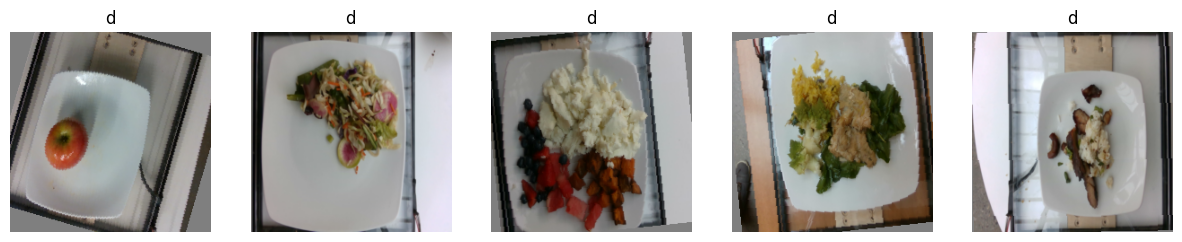

In [2]:
# prompt: create a function to visualize samples from the train_dataset

import matplotlib.pyplot as plt
import numpy as np

def visualize_samples(dataset, num_samples=5):
    """Visualizes samples from the dataset."""
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    for i in range(num_samples):
        sample, target = dataset[i]
        if sample is not None:  # Check for potential None values
          # Convert tensor to numpy array and handle different image formats
          if isinstance(sample, torch.Tensor):
              image = sample.permute(1, 2, 0).numpy()
          elif isinstance(sample, np.ndarray):
              image = sample
          else: # Assuming it's PIL image
              image = np.array(sample)

          # Normalize pixel values to the range 0-1 for display
          # image = (image - image.min()) / (image.max() - image.min())
          image = (image+1.)/2

          axes[i].imshow(image)
          axes[i].set_title(target[0])
          axes[i].axis('off')
    plt.show()

# Visualize samples from train_dataset
visualize_samples(train_dataset)


In [3]:
import torch
import torch.nn as nn
from torchvision import models

class CustomModel(nn.Module):
    def __init__(self, num_classes=5):
        super(CustomModel, self).__init__()
        # Load a pre-trained MobileNetV2 model (small model)
        self.model = models.mobilenet_v2( pretrained=True)

        # Freeze pre-trained layers
        for param in self.model.parameters():
           param.requires_grad = False

        # Modify the final classification layer
        num_ftrs = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(num_ftrs, 512)
        self.out_linear = nn.Linear(512, num_classes)

    def forward(self, x):
        c = self.model(x)
        c = torch.nn.functional.relu6(c)
        # return torch.nn.functional.relu(self.out_linear(c))
        return torch.exp(self.out_linear(c))

# Example usage:
model = CustomModel()


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
a = torch.normal(10, 2, size=(4,5))
print(a)
mean = torch.mean(a, axis=0)
print(mean)
std = torch.std(a, axis=0)
print(std)
norm_a = (a-mean)/std

print('norm_a', norm_a)

from_norm_a = norm_a*std+mean
print('from_norm_a', from_norm_a)


tensor([[12.4782, 10.9815, 11.7613, 10.7192, 10.6614],
        [ 3.1691, 10.4469,  9.5568,  8.0705,  9.0575],
        [10.6962,  8.8069,  7.4965,  8.4256,  8.3006],
        [ 6.7578, 10.5105, 11.6694, 10.4683,  6.6713]])
tensor([ 8.2753, 10.1865, 10.1210,  9.4209,  8.6727])
tensor([4.1594, 0.9501, 2.0244, 1.3659, 1.6580])
norm_a tensor([[ 1.0105,  0.8368,  0.8103,  0.9505,  1.1994],
        [-1.2276,  0.2741, -0.2787, -0.9887,  0.2321],
        [ 0.5820, -1.4520, -1.2964, -0.7287, -0.2244],
        [-0.3648,  0.3411,  0.7649,  0.7668, -1.2071]])
from_norm_a tensor([[12.4782, 10.9815, 11.7613, 10.7192, 10.6614],
        [ 3.1691, 10.4469,  9.5568,  8.0705,  9.0575],
        [10.6962,  8.8069,  7.4965,  8.4256,  8.3006],
        [ 6.7578, 10.5105, 11.6694, 10.4683,  6.6713]])


In [3]:
import torch
torch.nn.functional.relu

<function torch.nn.functional.relu(input: torch.Tensor, inplace: bool = False) -> torch.Tensor>

In [4]:
def evaluate():
  model.eval()
  threshold_a = 0.5
  threshold_a = 0.7
  correct_predictions = 0
  total_predictions = 0
  with torch.no_grad():
      for images, labels_raw in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Evaluation"):
          if images is None:
              continue

          images = images.to(device)
          labels = convert_labels(labels_raw)
          outputs = model(images)
          _, predicted = torch.max(outputs, 1)
          total_predictions += labels.size(0)
          correct_predictions += (predicted == labels).sum().item()

  accuracy = 100 * correct_predictions / total_predictions
  print(f"Epoch [{epoch+1}/{num_epochs}], Test Accuracy: {accuracy:.2f}%")

In [6]:
# carregar pesos no modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomModel().to(device)
model.load_state_dict(torch.load("./weights_scaling_log_mean_image/best_model.pth"))

<All keys matched successfully>

In [7]:
import torch
import torch.optim as optim
from tqdm import tqdm

def save_checkpoint(model, test_loss, save_dir="./weights_scaling_log_mean_image"):
    os.makedirs(save_dir, exist_ok=True)
    
    # Save last model weights (always overwrite)
    last_model_path = os.path.join(save_dir, "last_model.pth")
    torch.save(model.state_dict(), last_model_path)
    
    # Track best loss in a file to persist between runs
    best_loss_path = os.path.join(save_dir, "best_loss.txt")
    best_model_path = os.path.join(save_dir, "best_model.pth")
    
    # Initialize best loss
    best_loss = float('inf')
    if os.path.exists(best_loss_path):
        with open(best_loss_path, 'r') as f:
            best_loss = float(f.read())
    
    # Save new best model if current loss is better
    if test_loss < best_loss:
        print(f"New best model found! Loss improved from {best_loss:.4f} to {test_loss:.4f}")
        
        # Save best model weights
        torch.save(model.state_dict(), best_model_path)
        
        # Update best loss record
        with open(best_loss_path, 'w') as f:
            f.write(str(test_loss))

In [8]:
def loss_fn(y1, y):
    return torch.nn.functional.mse_loss(torch.sigmoid(y1), y)

def mag_loss(pred, labels):
    batch = pred.shape[0]
    probs = torch.sigmoid(pred)
    diff = probs - labels
    labels = labels.reshape(batch, 555, 2)
    diff = diff.reshape(batch, 555, 2)
    diff = diff.sum(-1)
    diff = torch.where(labels[..., 0]==1., diff*4, diff)
    mse = torch.mean(diff**2)
    return mse

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.00025) # Example optimizer

In [9]:
mean_scaling = torch.tensor([254.93, 218.01, 12.71, 19.33, 18.10]).to(device)
std_scaling = torch.tensor([220.97, 163.06, 13.41, 22.29, 20.22]).to(device)

def convert_labels(labels):
    # Placeholder: Implement your label conversion logic here.
    # This will take the output from get_csv_line() and convert it to numerical labels.
    # Example: Convert string labels to numerical IDs.
    targets = torch.zeros(len(labels), 5).to(device)
    for i, label in enumerate(labels):
        label = label.split(",")
        # ... your conversion logic ...
        #print(label)
        dish_id, total_calories, total_mass, total_fat, total_carb, total_protein = label[:6]
        ingrs = label[6:]
        for j in range(len(ingrs)//7):
          k = j*7
          #print(ingrs[k:k+7])
          ingr_id = int(ingrs[k].replace("ingr_", "")) - 1
          ingr_name = ingrs[k+1]
          ingr_mass = ingrs[k+2]

          # relative_mass = float(ingr_mass) / float(total_mass)

        #   targets[i, ingr_id*2] = 1.
        #   targets[i, ingr_id*2+1] = relative_mass

          targets[i, 0] = float(total_calories)
          targets[i, 1] = float(total_mass)
          targets[i, 2] = float(total_fat)
          targets[i, 3] = float(total_carb)
          targets[i, 4] = float(total_protein)

    return targets/mean_scaling

In [10]:
def validate():
    model.eval()
    running_loss = .0
    for images, labels_raw in tqdm(test_loader, desc=f"Evaluating"):
      
        if images is None or not torch.any(images):
            continue
        images = images.to(device)
        labels = convert_labels(labels_raw)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss+=loss.item()
    validation_loss = running_loss/len(test_loader)
    print('\nValidation loss:', validation_loss)
    return validation_loss
        

In [11]:
num_epochs = 10  # Set the number of epochs

def train(num_epochs):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels_raw in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            # Skip if images is None (due to missing image files)
            if images is None or not torch.any(images):
                continue

            images = images.to(device)
            labels = convert_labels(labels_raw)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {epoch_loss:.4f}")

        validation_loss = validate()
        save_checkpoint(model, validation_loss)


    print("Training finished.")


In [29]:
train(num_epochs)

Epoch 1/10 - Training: 100%|██████████| 87/87 [02:03<00:00,  1.42s/it]


Epoch [1/10], Training Loss: 0.8153


Evaluating: 100%|██████████| 16/16 [00:18<00:00,  1.17s/it]



Validation loss: 0.49523478746414185
New best model found! Loss improved from inf to 0.4952


Epoch 2/10 - Training: 100%|██████████| 87/87 [01:50<00:00,  1.27s/it]


...


Validation loss: 0.41788878105580807


Epoch 10/10 - Training: 100%|██████████| 87/87 [01:55<00:00,  1.33s/it]


Epoch [10/10], Training Loss: 0.5484


Evaluating: 100%|██████████| 16/16 [00:19<00:00,  1.19s/it]


Validation loss: 0.3791889250278473
New best model found! Loss improved from 0.3989 to 0.3792
Training finished.


In [56]:
for param in model.model.parameters():
    param.requires_grad = True
train(num_epochs)

Epoch 1/10 - Training: 100%|██████████| 87/87 [03:43<00:00,  2.57s/it]


Epoch [1/10], Training Loss: 0.5992


Evaluating: 100%|██████████| 16/16 [00:15<00:00,  1.06it/s]



Validation loss: 0.44788347743451595


Epoch 2/10 - Training: 100%|██████████| 87/87 [03:17<00:00,  2.27s/it]


...

Epoch 4/10 - Training: 100%|██████████| 87/87 [03:46<00:00,  2.61s/it]


Epoch [4/10], Training Loss: 0.4622


Evaluating: 100%|██████████| 16/16 [00:17<00:00,  1.08s/it]



Validation loss: 0.3499696971848607
New best model found! Loss improved from 0.3792 to 0.3500


Epoch 5/10 - Training:  45%|████▍     | 39/87 [02:15<03:02,  3.79s/it]

In [24]:
def evaluate():
    accuracy = 0
    n = 0
    current_acc = 0
    for images, labels_raw in tqdm(test_loader, desc=f"Evaluating"):
      
        if images is None or not torch.any(images):
            continue
        labels = convert_labels(labels_raw)
        threshold = 0.7

        model.eval()
        outputs = model(images)
        batch_size = outputs.shape[0]
        outputs = torch.sigmoid(outputs.reshape(batch_size, 555, 2))
        labels = labels.reshape(batch_size, 555, 2)
        probs = (outputs[..., 0] >= threshold).int()
        correct_preds = probs==(labels[..., 0].int())
        correct_preds = correct_preds.float().mean()
        current_acc = correct_preds
        accuracy += correct_preds
        n+=1

        #### ingredient regression accuracy
        ## absolute difference
        pred_pct = outputs[..., 1]
        true_pct = labels[..., 1]
        abs_diff = torch.abs(pred_pct-true_pct).mean()
        
        print(f"Batch acc: {correct_preds}\t ingr_diff: {abs_diff}")

    print(f"Accuracy: {(accuracy/n).detach().cpu().numpy()}")
        
    


In [26]:
device="cpu"
def evaluate_nutrients():
    accuracy = 0
    n = 0
    model.eval()
    running_diff = torch.tensor([0., 0, 0, 0, 0], requires_grad=False).to(device)

    for images, labels_raw in tqdm(test_loader, desc=f"Evaluating"):
      
        if images is None or not torch.any(images):
            continue
        images = images.to(device)
        labels = convert_labels(labels_raw)
        with torch.no_grad():
            outputs = model(images)
        images.detach()
        del images
        n+=1
        avg_diff = (outputs - labels).mean(0)
        
        avg_diff = avg_diff*mean_scaling
        avg_diff = torch.abs(avg_diff)
        running_diff += avg_diff
        
        # total_calories, total_mass, total_fat, total_carb, total_protein, 
        #print("Current diff\tCal:{:.1f}\tMass:{:.1f}\tFat:{:.1f}\tCarb:{:.1f}\tProt:{:.1f}".format(*avg_diff))
    diff = running_diff/n
    print("\n", "-"*50)
    print("Resultado - Erro médio absoluto:")
    print(f"Calorias:\t{diff[0]:.2f}")
    print(f"Massa:\t\t{diff[1]:.2f}")
    print(f"Lipídios:\t{diff[2]:.2f}")
    print(f"Carboidratos:\t{diff[3]:.2f}")
    print(f"Proteínas:\t{diff[4]:.2f}")
    return diff
        

In [27]:
evaluate_nutrients()

Evaluating: 100%|██████████| 16/16 [00:15<00:00,  1.06it/s]


 --------------------------------------------------
Resultado - Erro médio absoluto:
Calorias:	11.24
Massa:		25.22
Lipídios:	0.74
Carboidratos:	1.76
Proteínas:	2.52


tensor([11.2396, 25.2194,  0.7434,  1.7587,  2.5240])

In [47]:
evaluate_nutrients()

Evaluating:   6%|▋         | 1/16 [00:01<00:28,  1.90s/it]

Current diff\Cal:33.2	Mass:15.0	Fat:-0.7	Carb:0.8	Prot:-3.4
Current diff\Cal:30.9	Mass:36.0	Fat:-2.0	Carb:-0.6	Prot:-2.3


Evaluating:  19%|█▉        | 3/16 [00:03<00:13,  1.01s/it]

Current diff\Cal:61.8	Mass:32.7	Fat:1.1	Carb:0.7	Prot:-0.6
Current diff\Cal:45.1	Mass:28.0	Fat:-1.3	Carb:1.1	Prot:-0.2


Evaluating:  31%|███▏      | 5/16 [00:04<00:09,  1.17it/s]

...

Evaluating:  81%|████████▏ | 13/16 [00:10<00:02,  1.38it/s]

Current diff\Cal:24.7	Mass:5.6	Fat:-0.5	Carb:-2.0	Prot:-0.6
Current diff\Cal:17.0	Mass:22.3	Fat:-2.3	Carb:0.7	Prot:-2.7


Evaluating: 100%|██████████| 16/16 [00:11<00:00,  1.36it/s]

Current diff\Cal:31.6	Mass:27.1	Fat:-2.0	Carb:-0.3	Prot:-0.6
Current diff\Cal:15.7	Mass:23.4	Fat:-1.9	Carb:2.4	Prot:-5.7


NameError: name 'total_loss' is not defined

In [6]:
import torch
x = torch.normal(10, 1, size=(2,5)).to('cuda') / torch.tensor([10, 10, 5, 5, 2])
x

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [9]:
a = torch.tensor([0.3])
a.int()

tensor([0], dtype=torch.int32)

In [5]:
help(torch.gather)

Help on built-in function gather in module torch:

gather(...)
    gather(input, dim, index, *, sparse_grad=False, out=None) -> Tensor
    
    Gathers values along an axis specified by `dim`.
    
    For a 3-D tensor the output is specified by::
    
        out[i][j][k] = input[index[i][j][k]][j][k]  # if dim == 0
        out[i][j][k] = input[i][index[i][j][k]][k]  # if dim == 1
        out[i][j][k] = input[i][j][index[i][j][k]]  # if dim == 2
    
    :attr:`input` and :attr:`index` must have the same number of dimensions.
    It is also required that ``index.size(d) <= input.size(d)`` for all
    dimensions ``d != dim``.  :attr:`out` will have the same shape as :attr:`index`.
    Note that ``input`` and ``index`` do not broadcast against each other.
    
    Args:
        input (Tensor): the source tensor
        dim (int): the axis along which to index
        index (LongTensor): the indices of elements to gather
    
    Keyword arguments:
        sparse_grad (bool, optional): I

In [14]:
num_epochs = 10  # Set the number of epochs

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0

  for images, labels_raw in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
      # Skip if images is None (due to missing image files)
      if images is None or not torch.any(images):
          continue

      images = images.to(device)
      labels = convert_labels(labels_raw)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()

  epoch_loss = running_loss / len(train_loader)
  print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {epoch_loss:.4f}")

  # Evaluation loop


print("Training finished.")

Epoch 1/10 - Training: 100%|██████████| 87/87 [00:51<00:00,  1.69it/s]


Epoch [1/10], Training Loss: 0.0393


Epoch 2/10 - Training: 100%|██████████| 87/87 [00:48<00:00,  1.81it/s]


Epoch [2/10], Training Loss: 0.0373


Epoch 3/10 - Training: 100%|██████████| 87/87 [00:48<00:00,  1.81it/s]


...

Epoch [8/10], Training Loss: 0.0263


Epoch 9/10 - Training: 100%|██████████| 87/87 [00:48<00:00,  1.81it/s]


Epoch [9/10], Training Loss: 0.0253


Epoch 10/10 - Training: 100%|██████████| 87/87 [00:47<00:00,  1.81it/s]

Epoch [10/10], Training Loss: 0.0281
Training finished.


In [62]:
len(train_dataset)

330

In [ ]:
model.load_state_dict()

In [25]:
torch.save(model.state_dict(), 'model_weights_cal_regression.pth')

In [1]:
images, labels_raw = next(iter(test_loader))
images = images.to(device)
labels = convert_labels(labels_raw)
outputs = model(images)
import numpy as np
a = labels[2].detach().cpu().numpy()
b = torch.sigmoid(outputs[2]).detach().cpu().numpy()
print(np.argmax(a))
print(np.argmax(b))
print(list(a))
print("=============")
print(list(b))
print('.')
k = np.argmax(a)
print(a[k-2:k+2])
print(b[k-2:k+2])

NameError: name 'test_loader' is not defined

In [96]:
torch.nn.functional.mse_loss(torch.sigmoid(outputs[:1]), labels[:1])

tensor(0.0035, device='cuda:0', grad_fn=<MseLossBackward0>)

In [98]:
probs = torch.sigmoid(outputs[:1])
diff = probs - labels[:1]
diff = torch.where(labels==1., diff*10, diff)
mse = torch.mean(diff**2)
print(mse)

tensor(0.0566, device='cuda:0', grad_fn=<MeanBackward0>)


In [99]:
def mag_loss(pred, labels):
    probs = torch.sigmoid(pred)
    diff = probs - labels
    diff = torch.where(labels==1., diff*10, diff)
    mse = torch.mean(diff**2)
    return mse

In [43]:
with open("food_dataset/metadata/ingredients_metadata.csv") as file:
    class_names = [line.split(',')[0] for line in file][1:]
print("number os classes:", len(class_names))
    

number os classes: 555


In [46]:
# carregar pesos no modelo
model.load_state_dict(torch.load("./weights/best_model.pth"))

<All keys matched successfully>

In [34]:
def inference(img_path):
    model.eval()
    img = Image.open(img_path).convert('RGB')
    img = transform_train(img).unsqueeze(0).to(device)
    output = model(img)*mean_scaling
    print(output)
# dish_1558375833,317.032013,92.000000,25.116001,3.864000,17.756001
inference("./food_dataset/realsense_overhead/dish_1551314290/rgb.png")
# 240.425751,194.000000,10.293161,10.249402,25.324493

FileNotFoundError: [Errno 2] No such file or directory: './food_dataset/realsense_overhead/dish_1551314290/rgb.png'

In [63]:
model.load_state_dict(torch.load("./weights_scaling_log_mean/best_model.pth"))

<All keys matched successfully>

dish_1565035746    True    Pred
Cal                43.1   163.8
Mass              149.0   195.6
Fat                 0.4     6.9
Carb                9.0    11.7
Prot                2.4    16.0
--------------------------------------------------
dish_1558639818    True    Pred
Cal                20.1    56.0
Mass               59.0   100.2
Fat                 0.1     1.6
Carb                4.7    12.9
Prot                0.5     2.5
--------------------------------------------------
dish_1558549605    True    Pred
Cal                97.5   104.0
Mass               75.0   131.0
Fat                 0.2     3.8
Carb               21.0     9.7
Prot                2.0     7.6
--------------------------------------------------
dish_1561663580    True    Pred
Cal               432.1   405.5
Mass              307.0   289.7
Fat                 9.8    18.5
Carb               31.3    21.6
Prot               51.4    45.7
--------------------------------------------------
dish_1565898402    True    P

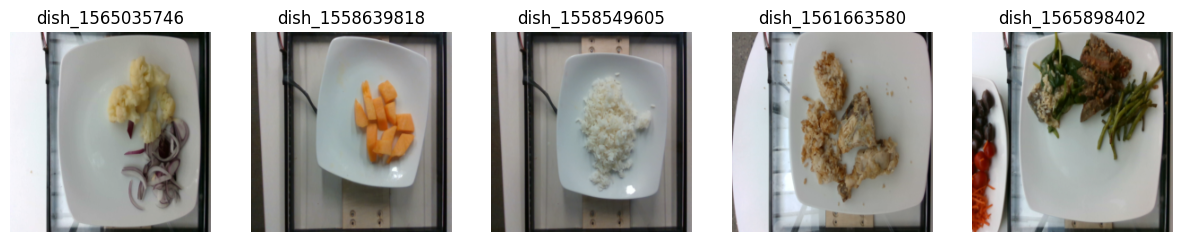

In [30]:
def visualize_from_test_dataset(num_samples=10):
    model.eval()
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    for i in range(num_samples):
        sample, target = test_dataset[i]
        if sample is not None:  # Check for potential None values
          # Convert tensor to numpy array and handle different image formats
          if isinstance(sample, torch.Tensor):
              image = sample.permute(1, 2, 0).numpy()
          elif isinstance(sample, np.ndarray):
              image = sample
          else: # Assuming it's PIL image
              image = np.array(sample)

          # Normalize pixel values to the range 0-1 for display
          image = (image - image.min()) / (image.max() - image.min())
          target = target.split(',')
          img_id = target[0]
          cal = float(target[1])
          mass = float(target[2])
          fat = float(target[3])
          carb = float(target[4])
          prot = float(target[5])

          output = model(sample.unsqueeze(0))*mean_scaling
          output = output.detach()

          axes[i].imshow(image)
          axes[i].set_title(img_id)
          axes[i].axis('off')
          print(f"{img_id}{'True': >8}{'Pred': >8}")
          print(f"Cal{cal:20.1f}{output[0,0]:8.1f}")
          print(f"Mass{mass:19.1f}{output[0,1]:8.1f}")
          print(f"Fat{fat:20.1f}{output[0,2]:8.1f}")
          print(f"Carb{carb:19.1f}{output[0,3]:8.1f}")
          print(f"Prot{prot:19.1f}{output[0,4]:8.1f}")
          print("-"*50)

    plt.show()

# Visualize samples from train_dataset
visualize_from_test_dataset(5)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def visualize_nutrition_distributions(data_list):
    """
    Visualizes nutritional distributions with multiple plots:
    - Histograms with KDE and statistics
    - Boxplots
    - Correlation heatmap
    """
    # Extract numerical values from the data
    nutrients = {
        'Total Calories': [],
        'Total Mass': [],
        'Total Fat': [],
        'Total Carb': [],
        'Total Protein': []
    }
    
    for item in data_list:
        nutrients['Total Calories'].append(float(item[1]))
        nutrients['Total Mass'].append(float(item[2]))
        nutrients['Total Fat'].append(float(item[3]))
        nutrients['Total Carb'].append(float(item[4]))
        nutrients['Total Protein'].append(float(item[5]))
    
    # Create main distribution plots
    fig, axs = plt.subplots(5, 2, figsize=(16, 24))
    plt.subplots_adjust(hspace=0.4)
    fig.suptitle('Nutritional Distributions Analysis', fontsize=20, y=0.99)
    
    for idx, (nutrient, values) in enumerate(nutrients.items()):
        # Convert to numpy array for easier calculations
        arr = np.array(values)
        
        # Histogram with statistics
        axs[idx, 0].hist(arr, bins=30, color='skyblue', edgecolor='black', density=True)
        axs[idx, 0].set_title(f'{nutrient} Distribution', fontsize=12)
        axs[idx, 0].set_xlabel(nutrient)
        axs[idx, 0].set_ylabel('Density')
        
        # Add statistical annotations
        stats_text = (f'Mean: {arr.mean():.2f}\n'
                      f'Median: {np.median(arr):.2f}\n'
                      f'Std Dev: {arr.std():.2f}\n'
                      f'Min: {arr.min():.2f}\n'
                      f'Max: {arr.max():.2f}')
        axs[idx, 0].text(0.98, 0.85, stats_text, transform=axs[idx, 0].transAxes,
                        ha='right', va='top', bbox=dict(facecolor='white', alpha=0.8))
        
        # Boxplot
        axs[idx, 1].boxplot(arr, vert=False, patch_artist=True,
                           boxprops=dict(facecolor='lightgreen'))
        axs[idx, 1].set_title(f'{nutrient} Boxplot', fontsize=12)
        axs[idx, 1].set_xlabel(nutrient)
        axs[idx, 1].set_yticks([])
    
    # Create correlation matrix heatmap
    df = pd.DataFrame({
        'Calories': nutrients['Total Calories'],
        'Mass': nutrients['Total Mass'],
        'Fat': nutrients['Total Fat'],
        'Carbs': nutrients['Total Carb'],
        'Protein': nutrients['Total Protein']
    })
    
    corr_matrix = df.corr()
    
    fig2, ax = plt.subplots(figsize=(10, 8))
    cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    fig2.colorbar(cax)
    
    # Set labels and annotations
    ax.set_xticks(np.arange(len(corr_matrix.columns)))
    ax.set_yticks(np.arange(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45)
    ax.set_yticklabels(corr_matrix.columns)
    ax.set_title('Nutrient Correlation Matrix', pad=20)
    
    # Add correlation values
    for (i, j), val in np.ndenumerate(corr_matrix):
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                color='white' if abs(val) < 0.5 else 'black')
    
    plt.tight_layout()
    plt.show()

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def visualize_nutrition_distributions_seaborn(data_list):
    """
    Visualizes nutritional distributions using Seaborn:
    - Histograms with KDE for each nutrient
    - Boxplots for each nutrient
    - Pairplot for relationships between nutrients
    - Correlation heatmap
    """
    # Convert data to a pandas DataFrame
    df = pd.DataFrame(data_list, columns=["img_id", "total_calories", "total_mass", 
                                          "total_fat", "total_carb", "total_protein"])
    
    # Convert numerical columns to float
    numerical_cols = ["total_calories", "total_mass", "total_fat", "total_carb", "total_protein"]
    df[numerical_cols] = df[numerical_cols].astype(float)
    
    # Set Seaborn style
    sns.set(style="whitegrid", palette="pastel")
    
    # Create a figure for histograms and boxplots
    fig, axes = plt.subplots(5, 2, figsize=(16, 20))
    fig.suptitle("Nutritional Distributions Analysis", fontsize=20, y=1.02)
    
    # Plot histograms and boxplots for each nutrient
    for i, col in enumerate(numerical_cols):
        # Histogram with KDE
        sns.histplot(df[col], kde=True, ax=axes[i, 0], color="skyblue", bins=30)
        axes[i, 0].set_title(f"{col.replace('_', ' ').title()} Distribution", fontsize=14)
        axes[i, 0].set_xlabel(col.replace('_', ' ').title())
        axes[i, 0].set_ylabel("Density")
        
        # Boxplot
        sns.boxplot(x=df[col], ax=axes[i, 1], color="lightgreen")
        axes[i, 1].set_title(f"{col.replace('_', ' ').title()} Boxplot", fontsize=14)
        axes[i, 1].set_xlabel(col.replace('_', ' ').title())
    
    plt.tight_layout()
    plt.show()
    
    # Pairplot to show relationships between nutrients
    print("\nPairplot of Nutritional Relationships:")
    sns.pairplot(df[numerical_cols], diag_kind="kde", corner=True, plot_kws={"s": 10})
    plt.suptitle("Pairplot of Nutritional Relationships", y=1.02)
    plt.show()
    
    # Correlation heatmap
    print("\nCorrelation Heatmap:")
    plt.figure(figsize=(10, 8))
    corr = df[numerical_cols].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, 
                linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title("Nutrient Correlation Heatmap", fontsize=16, pad=20)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

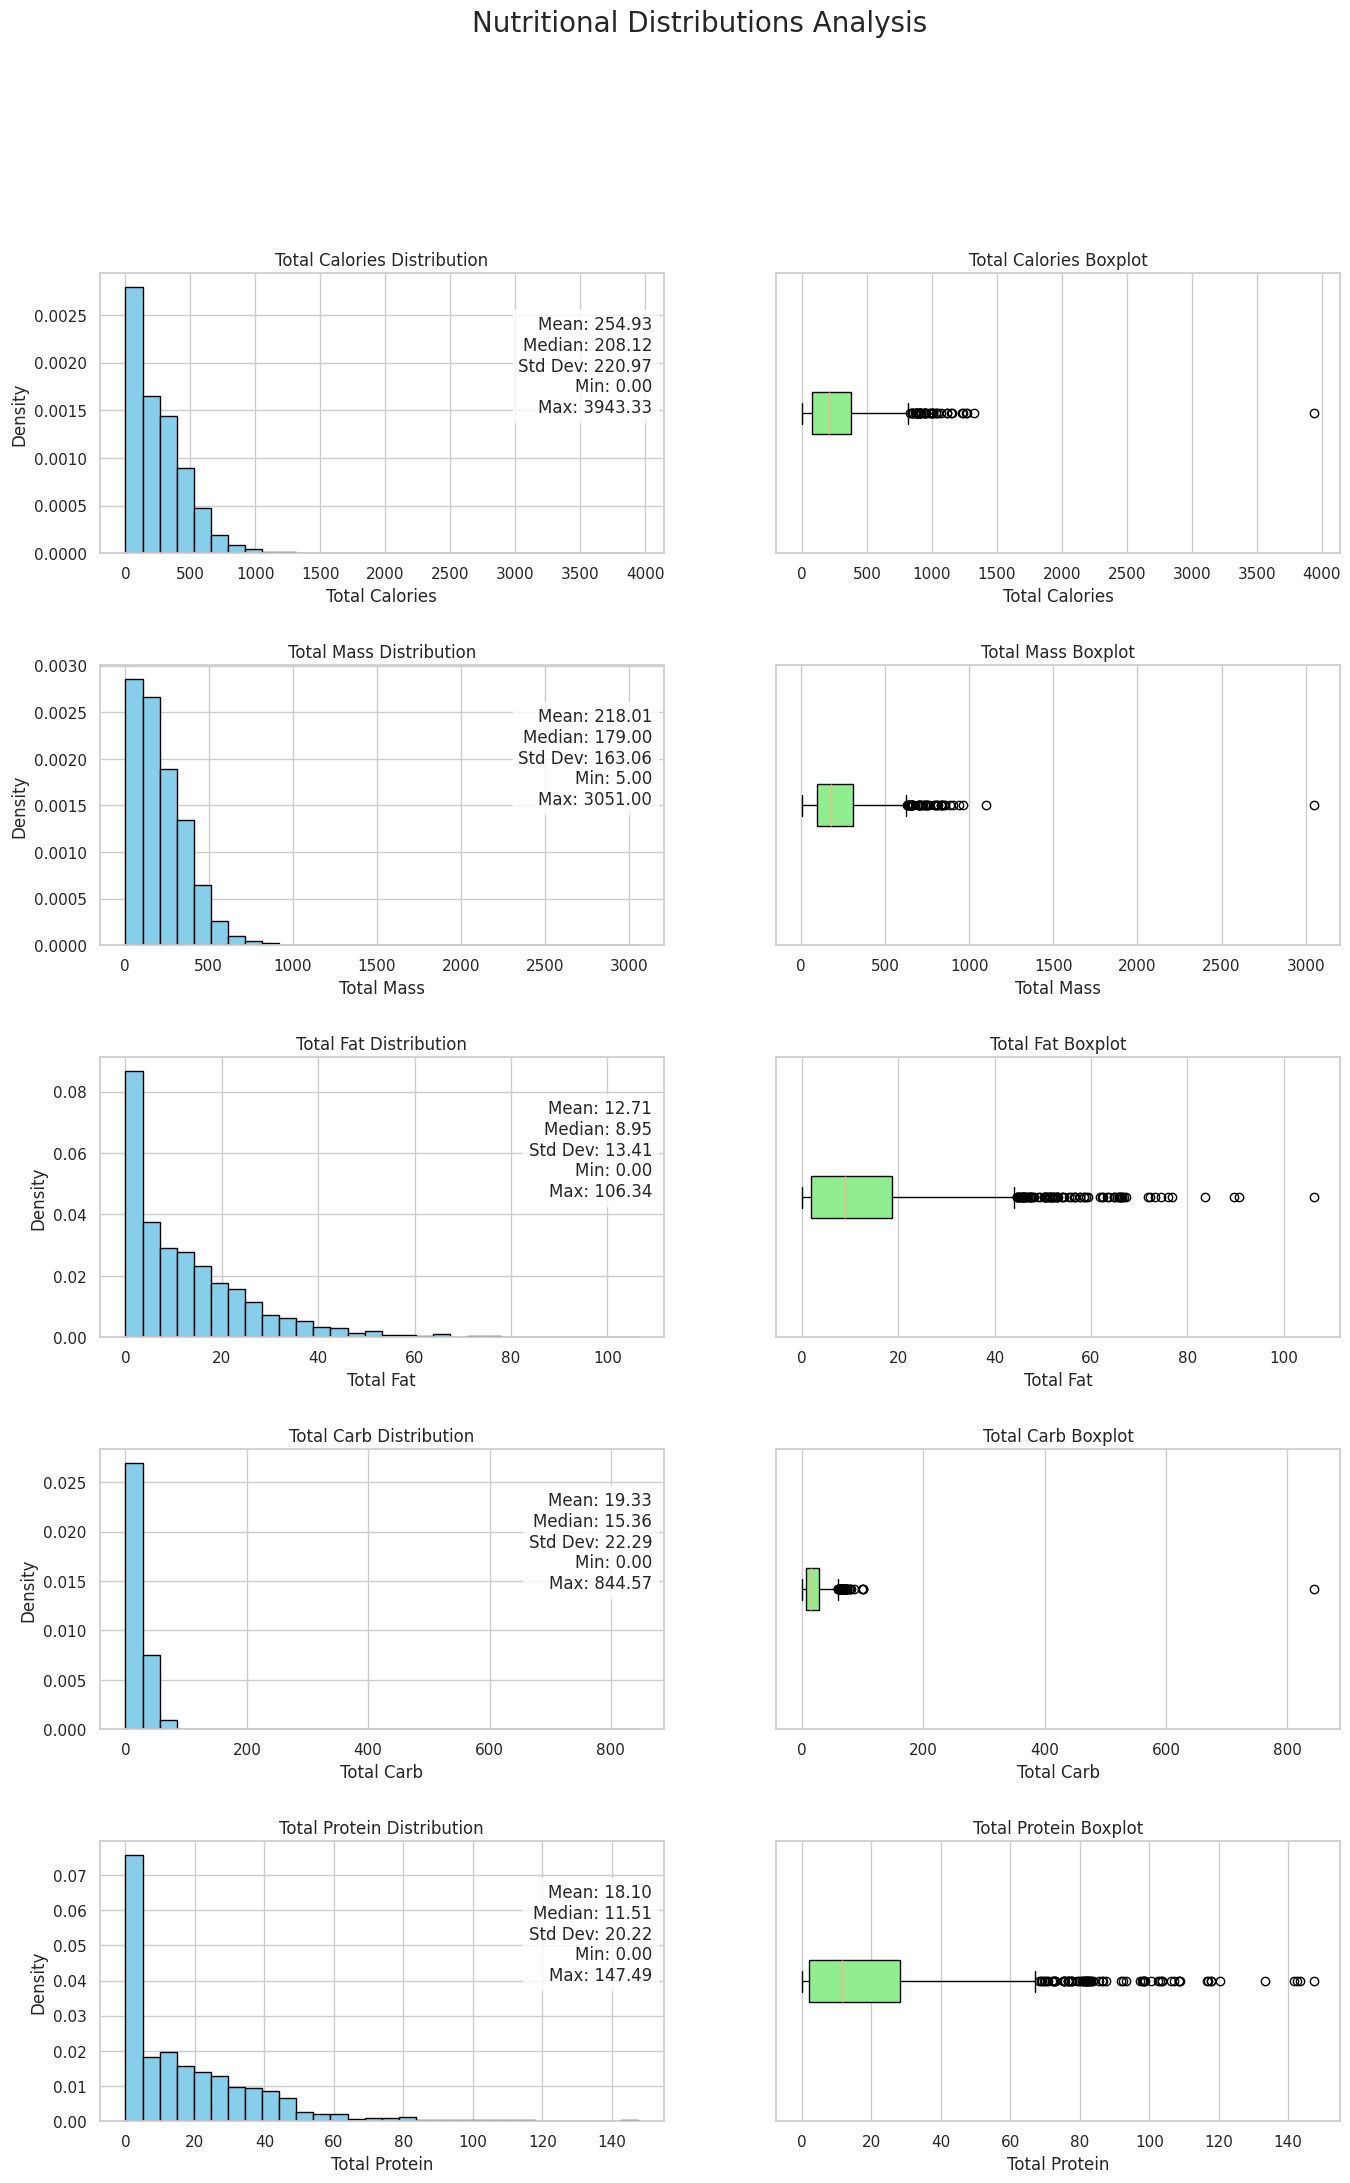

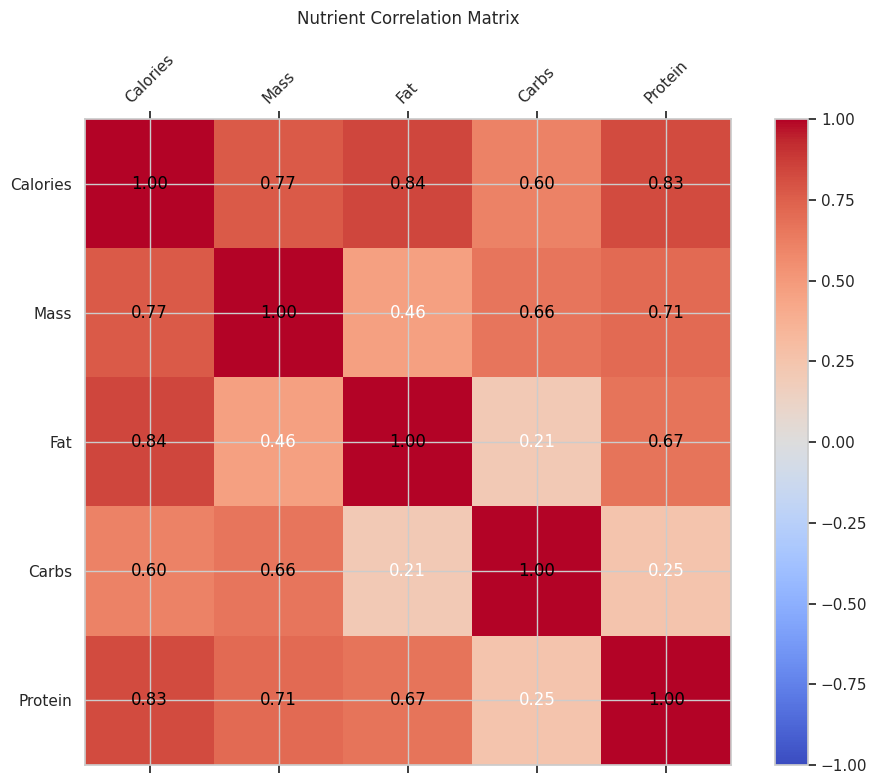

In [16]:
visualize_nutrition_distributions(i[1].split(',')[:6] for i in train_dataset)

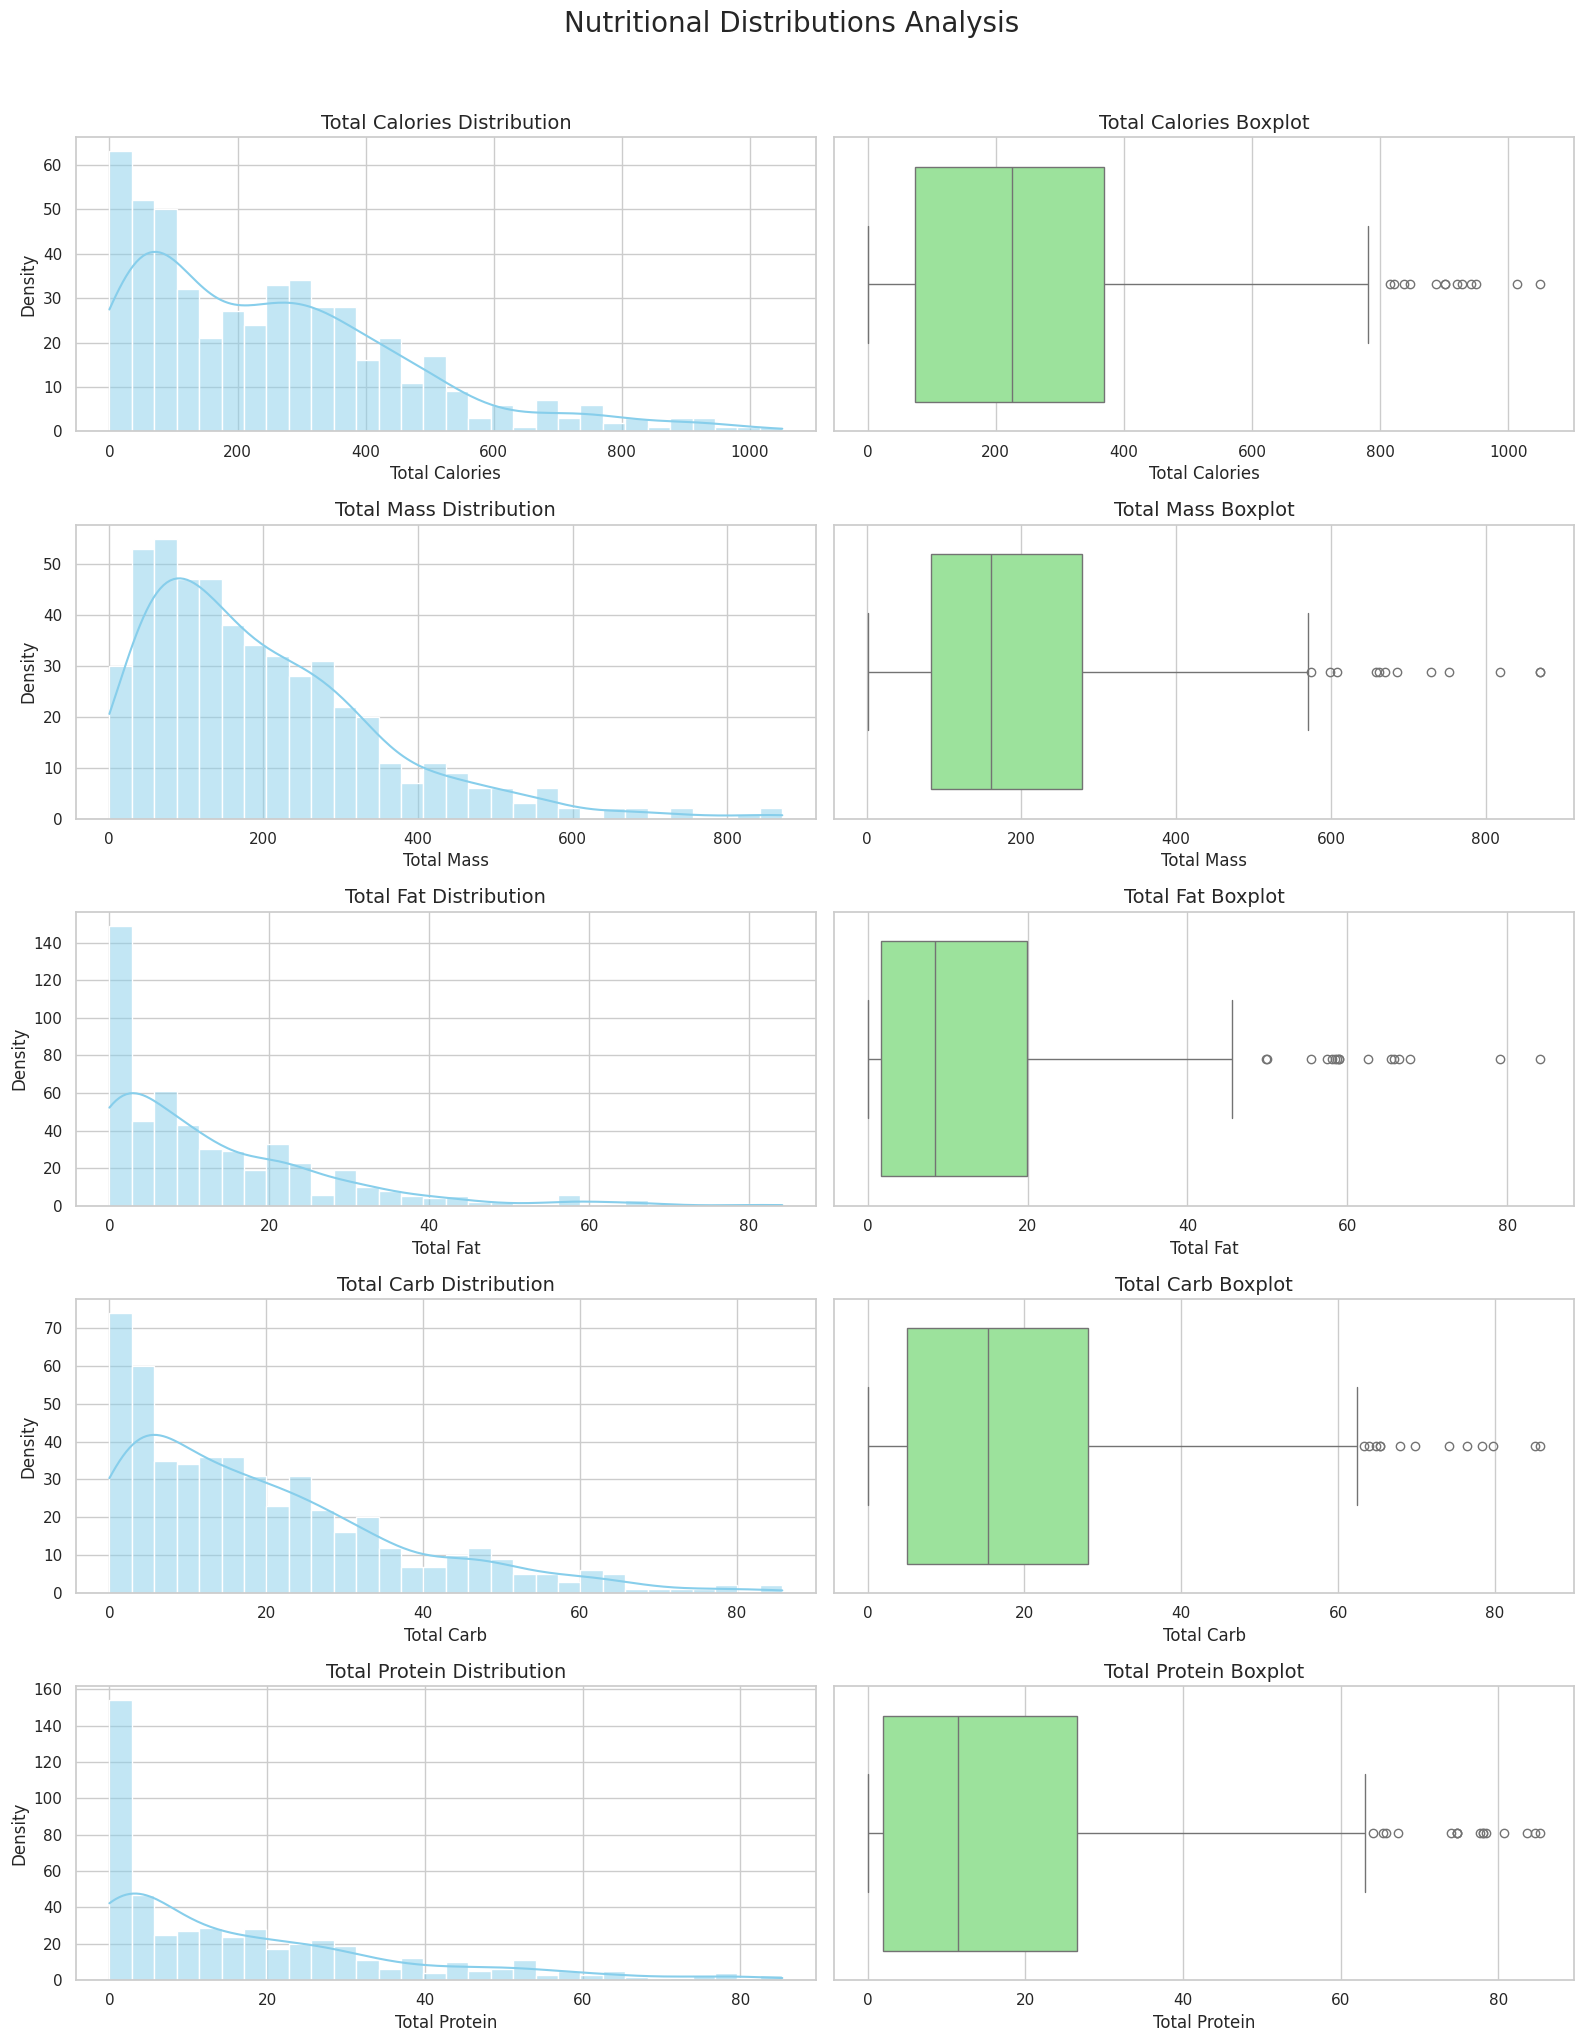


Pairplot of Nutritional Relationships:


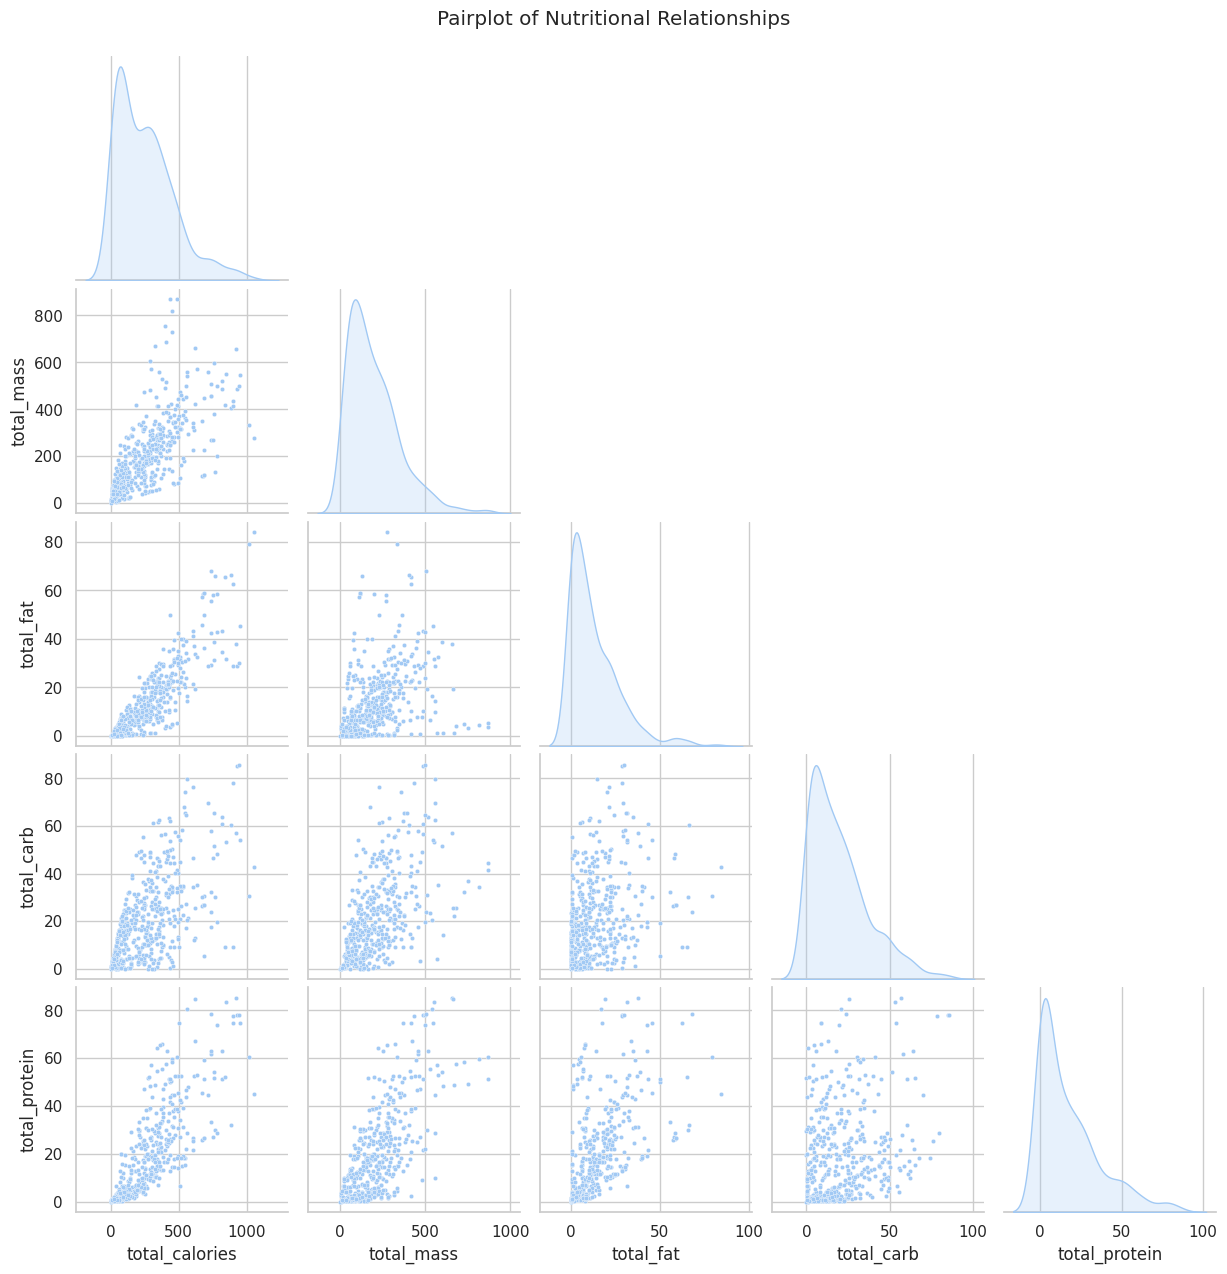


Correlation Heatmap:


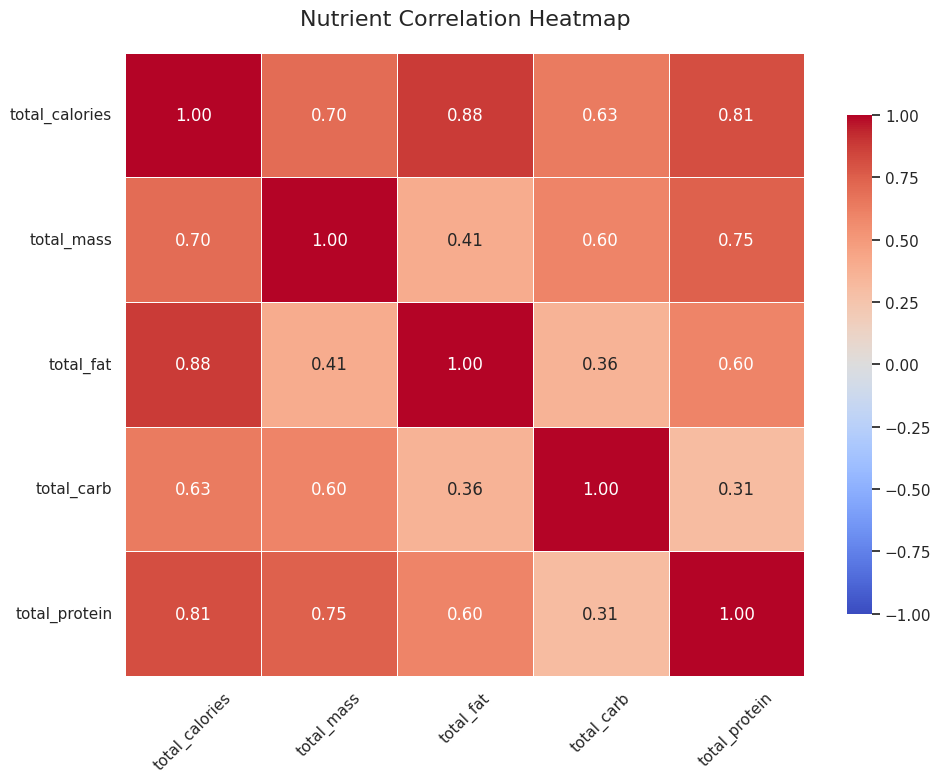

In [15]:

visualize_nutrition_distributions_seaborn(i[1].split(',')[:6] for i in test_dataset)

In [14]:
["img001", "525.5", "350.0", "32.1", "45.6", "24.8", "p"][:6]

['img001', '525.5', '350.0', '32.1', '45.6', '24.8']